In [ ]:
import sys, os
sys.path.append(os.path.abspath('..'))

Calculating Smooth State SVD...
Calculating True Model SVD...


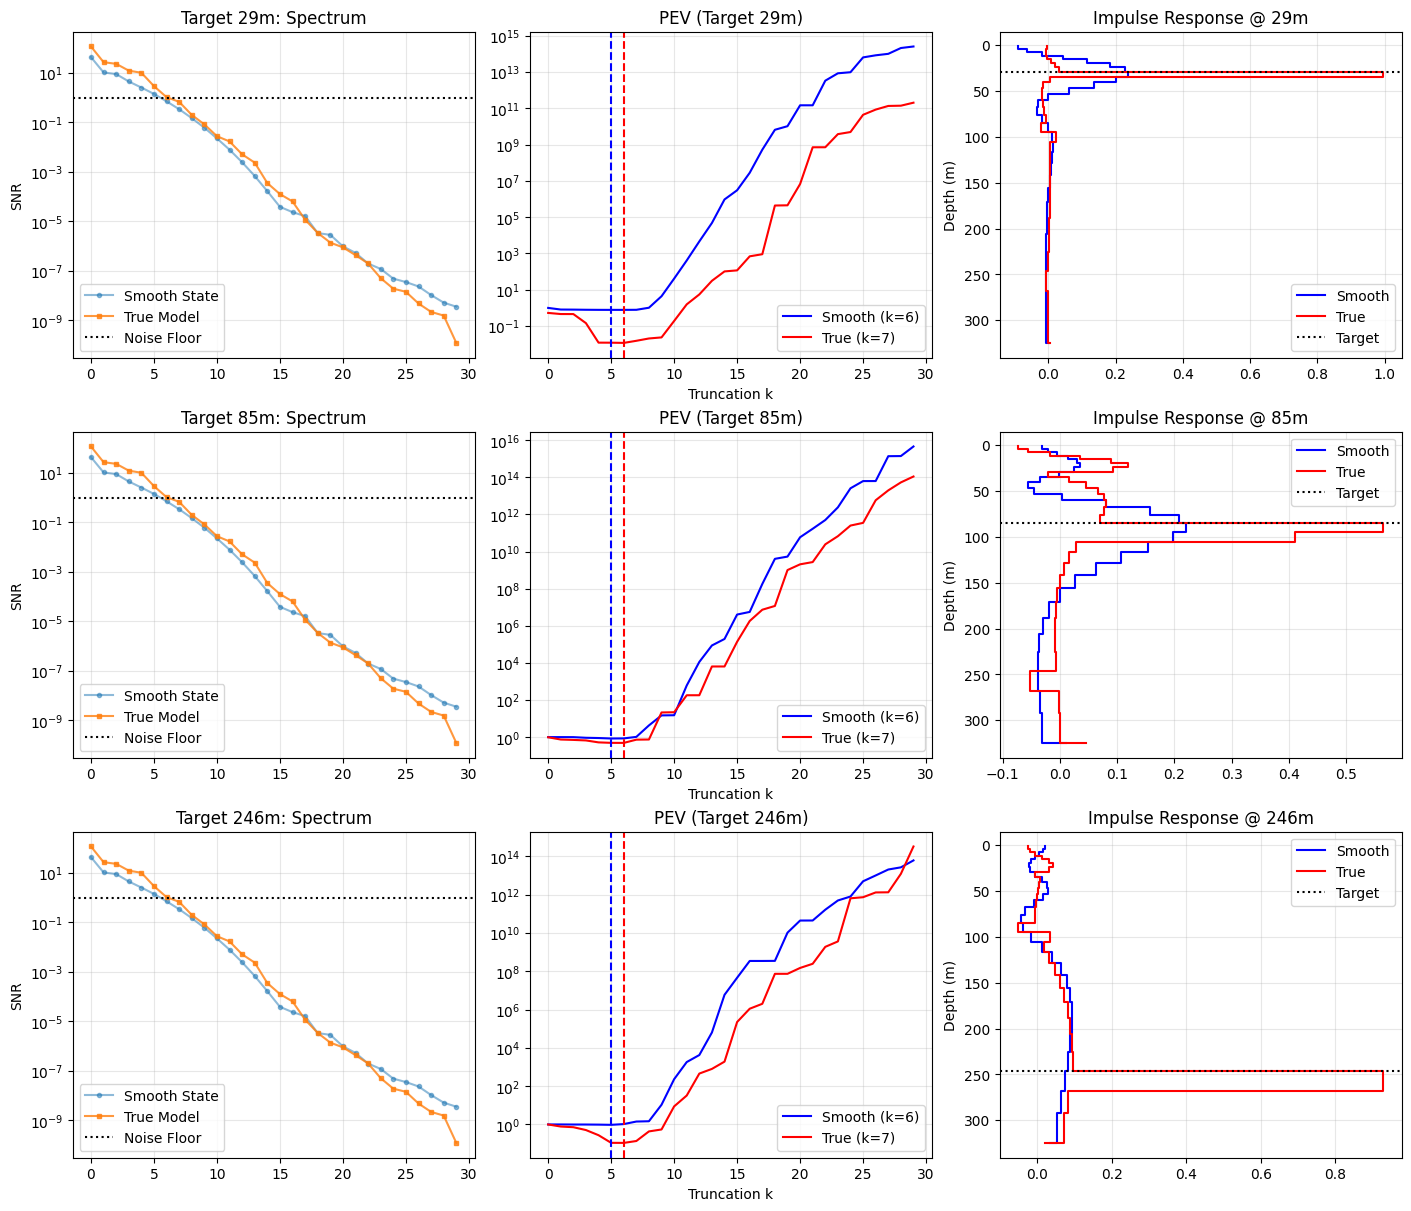

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from discretize import TensorMesh

try:
    from simpeg.solvers import ScipySolver
except ImportError:
    from pymatsolver import Solver as ScipySolver

# --- 1. SETUP SIMULATION ---
def get_simulation_and_models():
    # A. Mesh
    thicknesses = np.logspace(np.log10(3.0), np.log10(25.0), 29)
    mesh = TensorMesh([(np.r_[thicknesses, thicknesses[-1]])], "0")
    
    # B. True Model (The "Rough" State)
    sigma_true = np.ones(mesh.nC) * 0.01
    z_bot = np.cumsum(mesh.h[0])
    z_top = np.r_[0, z_bot[:-1]]
    
    # Define layers exactly as requested
    sigma_true[(z_top >= 25) & (z_top < 35)] = 0.3   # Layer 1
    sigma_true[(z_top >= 80) & (z_top < 100)] = 0.1   # Layer 2
    sigma_true[(z_top >= 220) & (z_top < 250)] = 0.1  # Layer 3
    
    # C. Smooth Model (The "Smooth" State)
    sigma_smooth = np.ones(mesh.nC) * 0.01

    # D. Survey Geometry (Standard AEM)
    rx_offset = np.array([13.0, 0.0, 0.0]) 
    tx_area = 1.0  
    lm_times = np.logspace(np.log10(1e-5), np.log10(1e-3), 20)
    hm_times = np.logspace(np.log10(1e-4), np.log10(1e-2), 20)
    
    src_loc = np.array([0.0, 0.0, 30.0]) 
    rx_loc = np.array([13.0, 0.0, 30.0]) 

    rx_lm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], lm_times, "z")
    rx_hm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], hm_times, "z")
    
    src_lm = tdem.sources.MagDipole([rx_lm], location=src_loc, orientation="z")
    src_hm = tdem.sources.MagDipole([rx_hm], location=src_loc, orientation="z")

    sim = tdem.Simulation1DLayered(
        survey=tdem.Survey([src_lm, src_hm]),
        thicknesses=thicknesses,
        sigmaMap=maps.ExpMap(nP=mesh.nC)
    )
    sim.solver = ScipySolver
    
    return sim, mesh, sigma_smooth, sigma_true

# --- 2. HELPER FUNCTIONS ---
def get_whitened_J(simulation, m_model,trueM):
    """Calculates Jacobian whitened by 3% Data Error."""
    f = simulation.fields(trueM)
    dpred = simulation.dpred(m_model, f=f)
    J = simulation.getJ(m_model, f=f)
    
    # Error Model: 3% relative error + noise floor
    std = np.abs(dpred) * 0.03 #+ 1e-13 
    Wd = np.diag(1.0 / std)
    
    # Whiten J
    Jw = Wd @ J
    return np.nan_to_num(Jw) # Safety clean

def calc_pev_curve(S, Vt, y, sigma_eps=1.0, prior_var=1.0):
    pevs = []
    n_params = len(y)
    for k in range(1, len(S) + 1):
        # Solution Noise (Amplified by small singular values)
        Vk = Vt[:k, :].T
        Sk_vals = S[:k]
        # Safety for division
        Sk_inv2 = np.diag(1.0 / (Sk_vals**2 + 1e-30))
        
        term1 = sigma_eps * (y.T @ Vk @ Sk_inv2 @ Vk.T @ y)
        
        # Null Space Error (Missing structural information)
        R = Vk @ Vk.T
        I = np.eye(n_params)
        Null = I - R
        term2 = prior_var * (y.T @ Null @ Null.T @ y)
        
        pevs.append(term1 + term2)
    return np.array(pevs)

def get_irf(Vt, k, target_idx):
    Vk = Vt[:k, :].T
    R = Vk @ Vk.T
    return R[target_idx, :] 

# --- 3. RUN ANALYSIS ---
sim, mesh, sigma_smooth, sigma_true = get_simulation_and_models()

# Calculate Depths for Plotting
thicknesses = mesh.h[0][:-1]
depths = np.cumsum(np.r_[0, thicknesses])
plot_depths = (depths[:-1] + depths[1:]) / 2 # Midpoints
plot_depths = np.r_[plot_depths, depths[-1] + 20] # Add halfspace

# Define Target Depths (Centers of the 3 Layers)
# Layer 1 (~30m), Layer 2 (~90m), Layer 3 (~180m)
targets = [30.0, 90.0, 250]

# Pre-Calculate SVDs for both states
print("Calculating Smooth State SVD...")
J_smooth_w = get_whitened_J(sim, np.log(sigma_smooth),np.log(sigma_true))
U_A, S_A, Vt_A = svd(J_smooth_w, full_matrices=False)

print("Calculating True Model SVD...")
J_true_w = get_whitened_J(sim, np.log(sigma_true),np.log(sigma_true))
U_B, S_B, Vt_B = svd(J_true_w, full_matrices=False)

# --- 4. PLOTTING ---
fig, axes = plt.subplots(len(targets), 3, figsize=(14, 4*len(targets)), constrained_layout=True)

for i, t_depth in enumerate(targets):
    # Find closest layer index
    t_idx = np.argmin(np.abs(plot_depths - t_depth))
    actual_depth = plot_depths[t_idx]
    
    # Calculate PEV
    target_vector = np.zeros(mesh.nC)
    target_vector[t_idx] = 1.0 
    
    pev_A = calc_pev_curve(S_A, Vt_A, target_vector)
    pev_B = calc_pev_curve(S_B, Vt_B, target_vector)
    
    k_opt_A = np.argmin(pev_A) + 1
    k_opt_B = np.argmin(pev_B) + 1
    
    
    ax_row = axes[i]
    
    # (a) Spectrum (Singular Values)
    ax_row[0].semilogy(S_A, 'o-', ms=3, label='Smooth State', alpha=0.5)
    ax_row[0].semilogy(S_B, 's-', ms=3, label='True Model', alpha=0.8)
    ax_row[0].axhline(1.0, color='k', ls=':', label='Noise Floor')
    ax_row[0].set_title(f"Target {actual_depth:.0f}m: Spectrum")
    ax_row[0].set_ylabel("SNR")
    ax_row[0].legend()
    ax_row[0].grid(True, alpha=0.3)
    
    # (b) PEV
    ax_row[1].semilogy(pev_A, 'b-', label=f'Smooth (k={k_opt_A})')
    ax_row[1].semilogy(pev_B, 'r-', label=f'True (k={k_opt_B})')
    ax_row[1].axvline(k_opt_A-1, color='b', ls='--')
    ax_row[1].axvline(k_opt_B-1, color='r', ls='--')
    ax_row[1].set_title(f"PEV (Target {actual_depth:.0f}m)")
    ax_row[1].set_xlabel("Truncation k")
    ax_row[1].legend()
    ax_row[1].grid(True, alpha=0.3)
    
    # (c) Impulse Response
    irf_A = get_irf(Vt_A, k_opt_A, t_idx)
    irf_B = get_irf(Vt_B, k_opt_B, t_idx)
    
    ax_row[2].step(irf_A, plot_depths, 'b-', ms=4, label=f'Smooth')
    ax_row[2].step(irf_B, plot_depths, 'r-', ms=4, label=f'True')
    ax_row[2].axhline(actual_depth, color='k', ls=':', label='Target')
    ax_row[2].invert_yaxis()
    ax_row[2].set_title(f"Impulse Response @ {actual_depth:.0f}m")
    ax_row[2].set_ylabel("Depth (m)")
    ax_row[2].legend()
    ax_row[2].grid(True, alpha=0.3)

plt.show()

Calculating Smooth State SVD...
Calculating True Model SVD...


C:\Users\SchoningG\AppData\Local\Temp\5\ipykernel_16124\2525280251.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


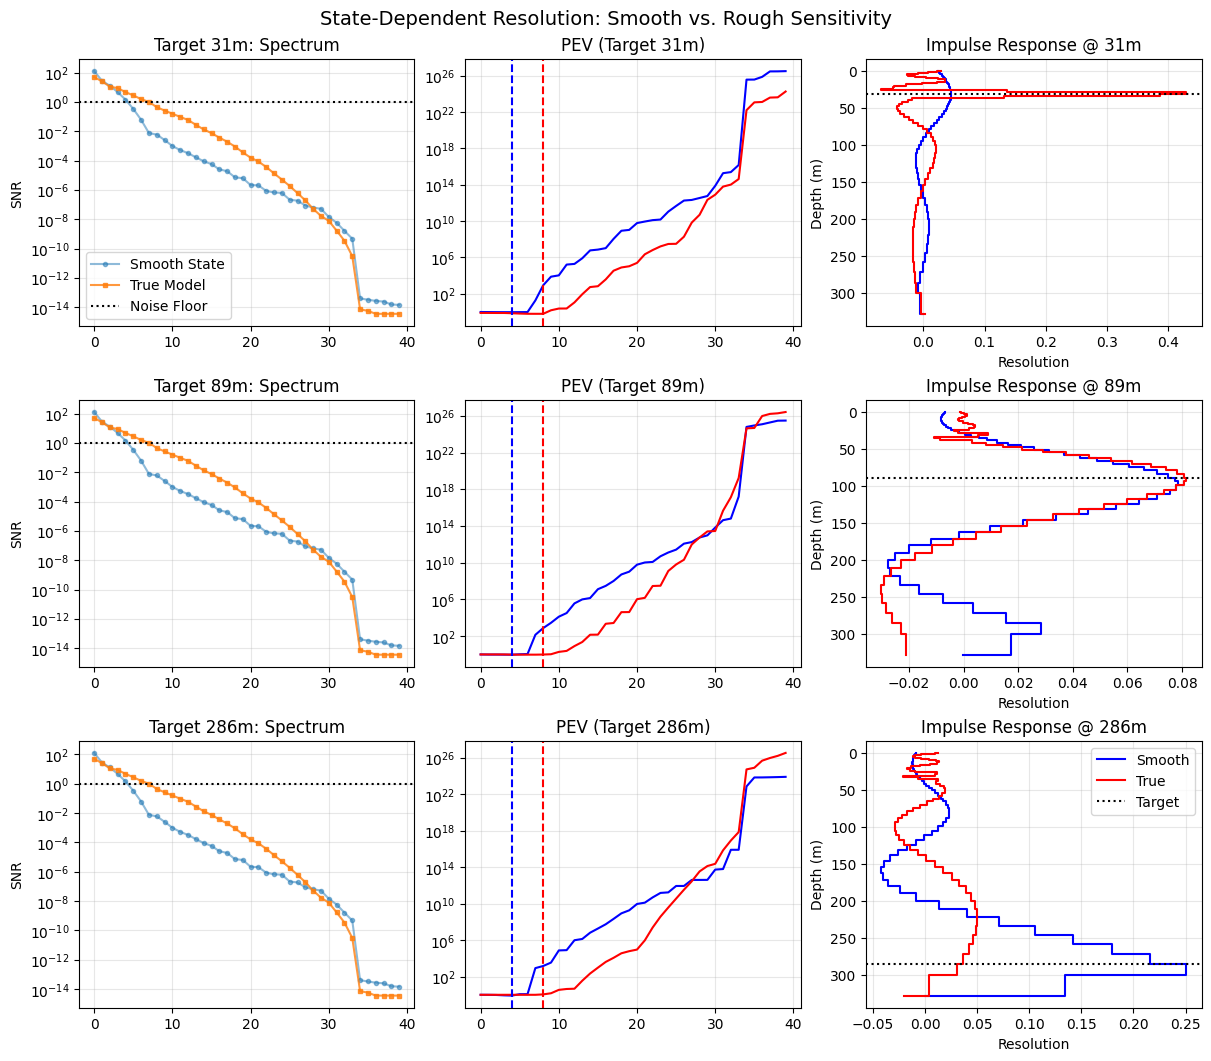

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from discretize import TensorMesh

try:
    from simpeg.solvers import ScipySolver
except ImportError:
    from pymatsolver import Solver as ScipySolver

# --- 1. SETUP SIMULATION ---
def get_simulation_and_models():
    # A. Mesh
    thicknesses = np.logspace(np.log10(1.0), np.log10(15.0), 59)
    mesh = TensorMesh([(np.r_[thicknesses, thicknesses[-1]])], "0")
    
    # B. True Model (The "Rough" State)
    # Background: 0.01 S/m
    sigma_true = np.ones(mesh.nC) * 0.1
    z_bot = np.cumsum(mesh.h[0])
    z_top = np.r_[0, z_bot[:-1]]
    
    # Add Targets
    sigma_true[(z_top >= 25) & (z_top < 35)] = 1    # Shallow
    sigma_true[(z_top >= 80) & (z_top < 100)] = 0.1   # Mid
    sigma_true[(z_top >= 250) & (z_top < 290)] = 0.1  # Deep
    
    # C. Smooth Model (The "Smooth" State)
    # FIX: Match background conductivity (0.01) to isolate structural effects
    sigma_smooth = np.ones(mesh.nC) * 0.001

    # D. Survey Geometry
    rx_offset = np.array([13.0, 0.0, 0.0]) 
    tx_area = 1.0  
    lm_times = np.logspace(np.log10(1e-5), np.log10(1e-3), 20)
    hm_times = np.logspace(np.log10(1e-4), np.log10(1e-2), 20)
    
    src_loc = np.array([0.0, 0.0, 30.0]) 
    rx_loc = np.array([13.0, 0.0, 30.0]) 

    rx_lm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], lm_times, "z")
    rx_hm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], hm_times, "z")
    
    src_lm = tdem.sources.MagDipole([rx_lm], location=src_loc, orientation="z")
    src_hm = tdem.sources.MagDipole([rx_hm], location=src_loc, orientation="z")

    sim = tdem.Simulation1DLayered(
        survey=tdem.Survey([src_lm, src_hm]),
        thicknesses=thicknesses,
        sigmaMap=maps.ExpMap(nP=mesh.nC)
    )
    sim.solver = ScipySolver
    
    return sim, mesh, sigma_smooth, sigma_true

# --- 2. HELPER FUNCTIONS ---
def get_whitened_J(simulation, m_model,trueM):
    """Calculates Jacobian whitened by 3% Data Error."""
    f = simulation.fields(trueM)
    dpred = simulation.dpred(m_model, f=f)
    J = simulation.getJ(m_model, f=f)
    
    # FIX: Added noise floor to prevent division by zero at late times
    # AEM signal decays exponentially; without this, weights explode.
    std = np.abs(dpred) * 0.03# + 1e-13 
    Wd = np.diag(1.0 / std)
    
    # Whiten J
    Jw = Wd @ J
    return np.nan_to_num(Jw) 

def calc_pev_curve(S, Vt, y, sigma_eps=1.0, prior_var=1.0):
    pevs = []
    n_params = len(y)
    for k in range(1, len(S) + 1):
        # Solution Noise
        Vk = Vt[:k, :].T
        Sk_vals = S[:k]
        # Safety for division
        Sk_inv2 = np.diag(1.0 / (Sk_vals**2 + 1e-30))
        
        term1 = sigma_eps * (y.T @ Vk @ Sk_inv2 @ Vk.T @ y)
        
        # Null Space Error
        R = Vk @ Vk.T
        I = np.eye(n_params)
        Null = I - R
        term2 = prior_var * (y.T @ Null @ Null.T @ y)
        
        pevs.append(term1 + term2)
    return np.array(pevs)

def get_irf(Vt, k, target_idx):
    Vk = Vt[:k, :].T
    R = Vk @ Vk.T
    return R[target_idx, :] 

# --- 3. RUN ANALYSIS ---
sim, mesh, sigma_smooth, sigma_true = get_simulation_and_models()

# Calculate Depths
thicknesses = mesh.h[0][:-1]
depths = np.cumsum(np.r_[0, thicknesses])
plot_depths = (depths[:-1] + depths[1:]) / 2 
plot_depths = np.r_[plot_depths, depths[-1] + 20] 

# Targets
targets = [30.0, 90.0, 290.0] # Adjusted deep target to center of layer

print("Calculating Smooth State SVD...")
J_smooth_w = get_whitened_J(sim, np.log(sigma_smooth))
U_A, S_A, Vt_A = svd(J_smooth_w, full_matrices=False)

print("Calculating True Model SVD...")
J_true_w = get_whitened_J(sim, np.log(sigma_true))
U_B, S_B, Vt_B = svd(J_true_w, full_matrices=False)

# --- 4. PLOTTING ---
fig, axes = plt.subplots(len(targets), 3, figsize=(12, 3.5*len(targets)), constrained_layout=True)

for i, t_depth in enumerate(targets):
    t_idx = np.argmin(np.abs(plot_depths - t_depth))
    actual_depth = plot_depths[t_idx]
    
    # Calculate PEV
    target_vector = np.zeros(mesh.nC)
    target_vector[t_idx] = 1.0 
    
    pev_A = calc_pev_curve(S_A, Vt_A, target_vector)
    pev_B = calc_pev_curve(S_B, Vt_B, target_vector)
    
    k_opt_A = np.argmin(pev_A) + 1
    k_opt_B = np.argmin(pev_B) + 1+1
    
    ax_row = axes[i]
    
    # (a) Spectrum
    ax_row[0].semilogy(S_A, 'o-', ms=3, label='Smooth State', alpha=0.5)
    ax_row[0].semilogy(S_B, 's-', ms=3, label='True Model', alpha=0.8)
    ax_row[0].axhline(1.0, color='k', ls=':', label='Noise Floor')
    ax_row[0].set_title(f"Target {actual_depth:.0f}m: Spectrum")
    ax_row[0].set_ylabel("SNR")
    if i==0: ax_row[0].legend()
    ax_row[0].grid(True, alpha=0.3)
    
    # (b) PEV
    ax_row[1].semilogy(pev_A, 'b-', label=f'Smooth (k={k_opt_A})')
    ax_row[1].semilogy(pev_B, 'r-', label=f'True (k={k_opt_B})')
    ax_row[1].axvline(k_opt_A-1, color='b', ls='--')
    ax_row[1].axvline(k_opt_B-1, color='r', ls='--')
    ax_row[1].set_title(f"PEV (Target {actual_depth:.0f}m)")
    ax_row[1].grid(True, alpha=0.3)
    
    # (c) Impulse Response
    irf_A = get_irf(Vt_A, k_opt_A, t_idx)
    irf_B = get_irf(Vt_B, k_opt_B, t_idx)
    
    # Using step plot for 1D blocky models looks cleaner
    ax_row[2].step(irf_A, plot_depths, 'b-', where='mid', label=f'Smooth')
    ax_row[2].step(irf_B, plot_depths, 'r-', where='mid', label=f'True')
    ax_row[2].axhline(actual_depth, color='k', ls=':', label='Target')
    ax_row[2].invert_yaxis()
    ax_row[2].set_title(f"Impulse Response @ {actual_depth:.0f}m")
    ax_row[2].set_xlabel("Resolution")
    ax_row[2].set_ylabel("Depth (m)")
    ax_row[2].grid(True, alpha=0.3)
    plt.legend()

plt.suptitle("State-Dependent Resolution: Smooth vs. Rough Sensitivity", fontsize=14)
plt.show()

Running Stochastic Ensemble (N=100)...


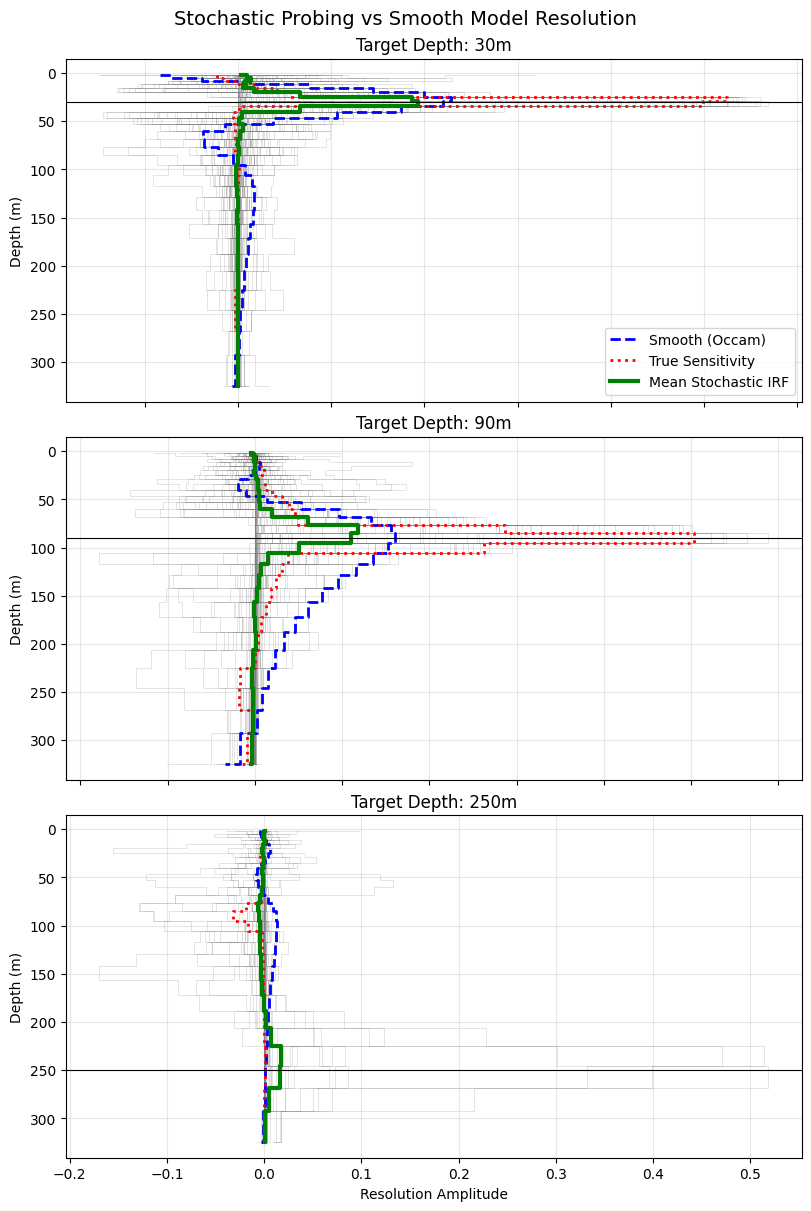

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from discretize import TensorMesh

try:
    from simpeg.solvers import ScipySolver
except ImportError:
    from pymatsolver import Solver as ScipySolver

# --- 1. SETUP SIMULATION ---
def get_condamine_simulation():
    # Mesh
    thicknesses = np.logspace(np.log10(3.0), np.log10(25.0), 29)
    mesh = TensorMesh([(np.r_[thicknesses, thicknesses[-1]])], "0")
    
    # Survey
    rx_offset = np.array([13.0, 0.0, 0.0]) 
    tx_area = 1.0  
    lm_times = np.logspace(np.log10(1e-5), np.log10(1e-3), 20)
    hm_times = np.logspace(np.log10(1e-4), np.log10(1e-2), 20)
    
    src_loc = np.array([0.0, 0.0, 30.0]) 
    rx_loc = np.array([13.0, 0.0, 30.0]) 

    rx_lm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], lm_times, "z")
    rx_hm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], hm_times, "z")
    
    src_lm = tdem.sources.MagDipole([rx_lm], location=src_loc, orientation="z")
    src_hm = tdem.sources.MagDipole([rx_hm], location=src_loc, orientation="z")

    sim = tdem.Simulation1DLayered(
        survey=tdem.Survey([src_lm, src_hm]),
        thicknesses=thicknesses,
        sigmaMap=maps.ExpMap(nP=mesh.nC)
    )
    sim.solver = ScipySolver
    return sim, mesh

# --- 2. HELPER FUNCTIONS ---
def get_whitened_J(simulation, m_model, m_true):
    """
    Calculates Jacobian for m_model, but whitens it using 
    the error envelope from m_true (Observed Data).
    """
    try:
        # 1. Calculate the 'Observed Data' (Noise Envelope source)
        # We only need this ONCE to define the weighting matrix
        f_true = simulation.fields(m_true)
        d_true = simulation.dpred(m_true, f=f_true)
        
        # Define Noise Envelope based on TRUE data
        # (This ensures both Smooth and Rough J are scaled identically)
        std_true = np.abs(d_true) * 0.05 + 1e-13
        Wd = np.diag(1.0 / std_true)
        
        # 2. Calculate Jacobian for the MODEL we are testing
        # We MUST recalculate fields for m_model
        f_model = simulation.fields(m_model)
        J_model = simulation.getJ(m_model, f=f_model)
        
        # 3. Whiten J_model using Wd_true
        Jw = Wd @ J_model
        
        return np.nan_to_num(Jw)
    except Exception as e:
        print(f"Jacobian calculation failed: {e}")
        return None

def calc_k_opt(S, Vt, y, sigma_eps=1.0, prior_var=1.0):
    """Finds optimal truncation k for a specific target vector y."""
    pevs = []
    n_params = len(y)
    for k in range(1, len(S) + 1):
        Vk = Vt[:k, :].T
        Sk_vals = S[:k]
        Sk_inv2 = np.diag(1.0 / (Sk_vals**2 + 1e-30))
        
        # PEV Terms
        term1 = sigma_eps * (y.T @ Vk @ Sk_inv2 @ Vk.T @ y) # Noise
        
        R = Vk @ Vk.T
        I = np.eye(n_params)
        Null = I - R
        term2 = prior_var * (y.T @ Null @ Null.T @ y) # Null Space
        
        pevs.append(term1 + term2)
    
    return np.argmin(pevs) + 1

def get_irf(Vt, k, target_idx):
    Vk = Vt[:k, :].T
    R = Vk @ Vk.T
    return R[target_idx, :] 

# --- 3. GENERATE STOCHASTIC MODELS ---
def generate_random_model(mesh, correlation_len=2):
    """Generates a random correlated model (simulating SLI prior)."""
    # 1. Create Correlation Matrix (Gaussian)
    nC = mesh.nC
    idx = np.arange(nC)
    dist = np.abs(idx[:, None] - idx[None, :])
    C = np.exp(-(dist**2) / (2 * correlation_len**2)) + np.eye(nC)*1e-6
    
    # 2. Cholesky L
    try:
        L = np.linalg.cholesky(C)
    except:
        # Fallback to SVD if Cholesky fails
        U, S, _ = np.linalg.svd(C)
        L = U @ np.diag(np.sqrt(S))
        
    # 3. Random Latent Vector z ~ N(0, 1)
    z = np.random.randn(nC)
    
    # 4. Map to Conductivity
    perturbation = L @ z
    # Scale perturbation (approx +/- 1.5 log units)
    perturbation = perturbation / np.std(perturbation) * 2
    
    # FIX: Base on 0.01 S/m (same as True Background)
    m_rand = np.log(0.01) + perturbation
    return m_rand

# --- 4. RUN THE EXPERIMENT ---
sim, mesh = get_condamine_simulation()
thicknesses = mesh.h[0][:-1]
depths = np.cumsum(np.r_[0, thicknesses])
plot_depths = (depths[:-1] + depths[1:]) / 2 
plot_depths = np.r_[plot_depths, depths[-1] + 20] 

# Targets: Shallow, Mid, Deep
targets = [30.0, 90.0, 250.0]
n_realizations = 100

fig, axes = plt.subplots(len(targets), 1, figsize=(8, 12), constrained_layout=True)

# 1. BASELINES (Calculate once)
# Smooth (Occam Baseline)
# FIX: Use 0.01 to match True background. 0.001 would bias skin depth.
sigma_smooth = np.ones(mesh.nC) * 0.01 


# True Model
sigma_true = np.ones(mesh.nC) * 0.01
z_bot = np.cumsum(mesh.h[0]); z_top = np.r_[0, z_bot[:-1]]
# Define layers
sigma_true[(z_top >= 25) & (z_top < 35)] = 0.3    # Layer 1
sigma_true[(z_top >= 80) & (z_top < 100)] = 0.1   # Layer 2
sigma_true[(z_top >= 220) & (z_top < 250)] = 0.1  # Layer 3
J_smooth = get_whitened_J(sim, np.log(sigma_smooth),np.log(sigma_true))
U_S, S_S, Vt_S = svd(J_smooth, full_matrices=False)
J_true = get_whitened_J(sim, np.log(sigma_true),np.log(sigma_true))

U_T, S_T, Vt_T = svd(J_true, full_matrices=False)

print(f"Running Stochastic Ensemble (N={n_realizations})...")

for i, t_depth in enumerate(targets):
    t_idx = np.argmin(np.abs(plot_depths - t_depth))
    target_vec = np.zeros(mesh.nC); target_vec[t_idx] = 1.0
    
    # --- A. Smooth IRF ---
    k_smooth = calc_k_opt(S_S, Vt_S, target_vec)
    irf_smooth = get_irf(Vt_S, k_smooth, t_idx)
    
    # --- B. True IRF ---
    k_true = calc_k_opt(S_T, Vt_T, target_vec)
    irf_true = get_irf(Vt_T, k_true, t_idx)
    
    # --- C. Stochastic IRFs ---
    irf_stack = []
    
    for r in range(n_realizations):
        # Generate Random Model
        m_rand = generate_random_model(mesh, correlation_len=2.0)
        
        # Calculate J for this random state
        J_rand = get_whitened_J(sim, m_rand,np.log(sigma_true))
        
        if J_rand is not None:
            try:
                # SVD
                U_r, S_r, Vt_r = svd(J_rand, full_matrices=False)
                # Dynamic Optimal Truncation
                k_rand = calc_k_opt(S_r, Vt_r, target_vec)
                # Get IRF
                irf_r = get_irf(Vt_r, k_rand, t_idx)
                irf_stack.append(irf_r)
            except:
                pass # Skip unstable SVDs
    
    # Calculate Mean and Std
    irf_stack = np.array(irf_stack)
    irf_mean = np.mean(irf_stack, axis=0)
    irf_std = np.std(irf_stack, axis=0)
    
    # --- PLOTTING ---
    ax = axes[i]
    
    # 1. Grey Spaghetti (Realizations)
    for irf in irf_stack: 
        ax.step(irf, plot_depths, color='gray', alpha=0.3, lw=0.5, where='mid')
        
    # 2. Smooth Baseline (Blue Dashed)
    ax.step(irf_smooth, plot_depths, 'b--', lw=2.0, where='mid', label='Smooth (Occam)')
    
    # 3. True Baseline (Red Dotted) - "The Goal"
    ax.step(irf_true, plot_depths, 'r:', lw=2.0, where='mid', label='True Sensitivity')
    
    # 4. Stochastic Mean (Green Solid) - "Our Result"
    ax.step(irf_mean, plot_depths, 'g-', lw=3.0, where='mid', label='Mean Stochastic IRF')
    
    # 5. Uncertainty Shade
   # ax.fill_betweenx(plot_depths, irf_mean - irf_std, irf_mean + irf_std, color='g', alpha=0.1, step='mid')
    
    ax.axhline(t_depth, color='k', ls='-', lw=0.8)
    ax.invert_yaxis()
    ax.set_title(f"Target Depth: {t_depth:.0f}m")
    ax.set_ylabel("Depth (m)")
    
    if i == len(targets)-1: 
        ax.set_xlabel("Resolution Amplitude")
    else:
        ax.set_xticklabels([])
        
    ax.grid(True, alpha=0.3)
    if i == 0: ax.legend(loc='lower right')

plt.suptitle("Stochastic Probing vs Smooth Model Resolution", fontsize=14)
plt.show()

Calculating Baseline Jacobians...
Running Stochastic Ensemble (N=100)...


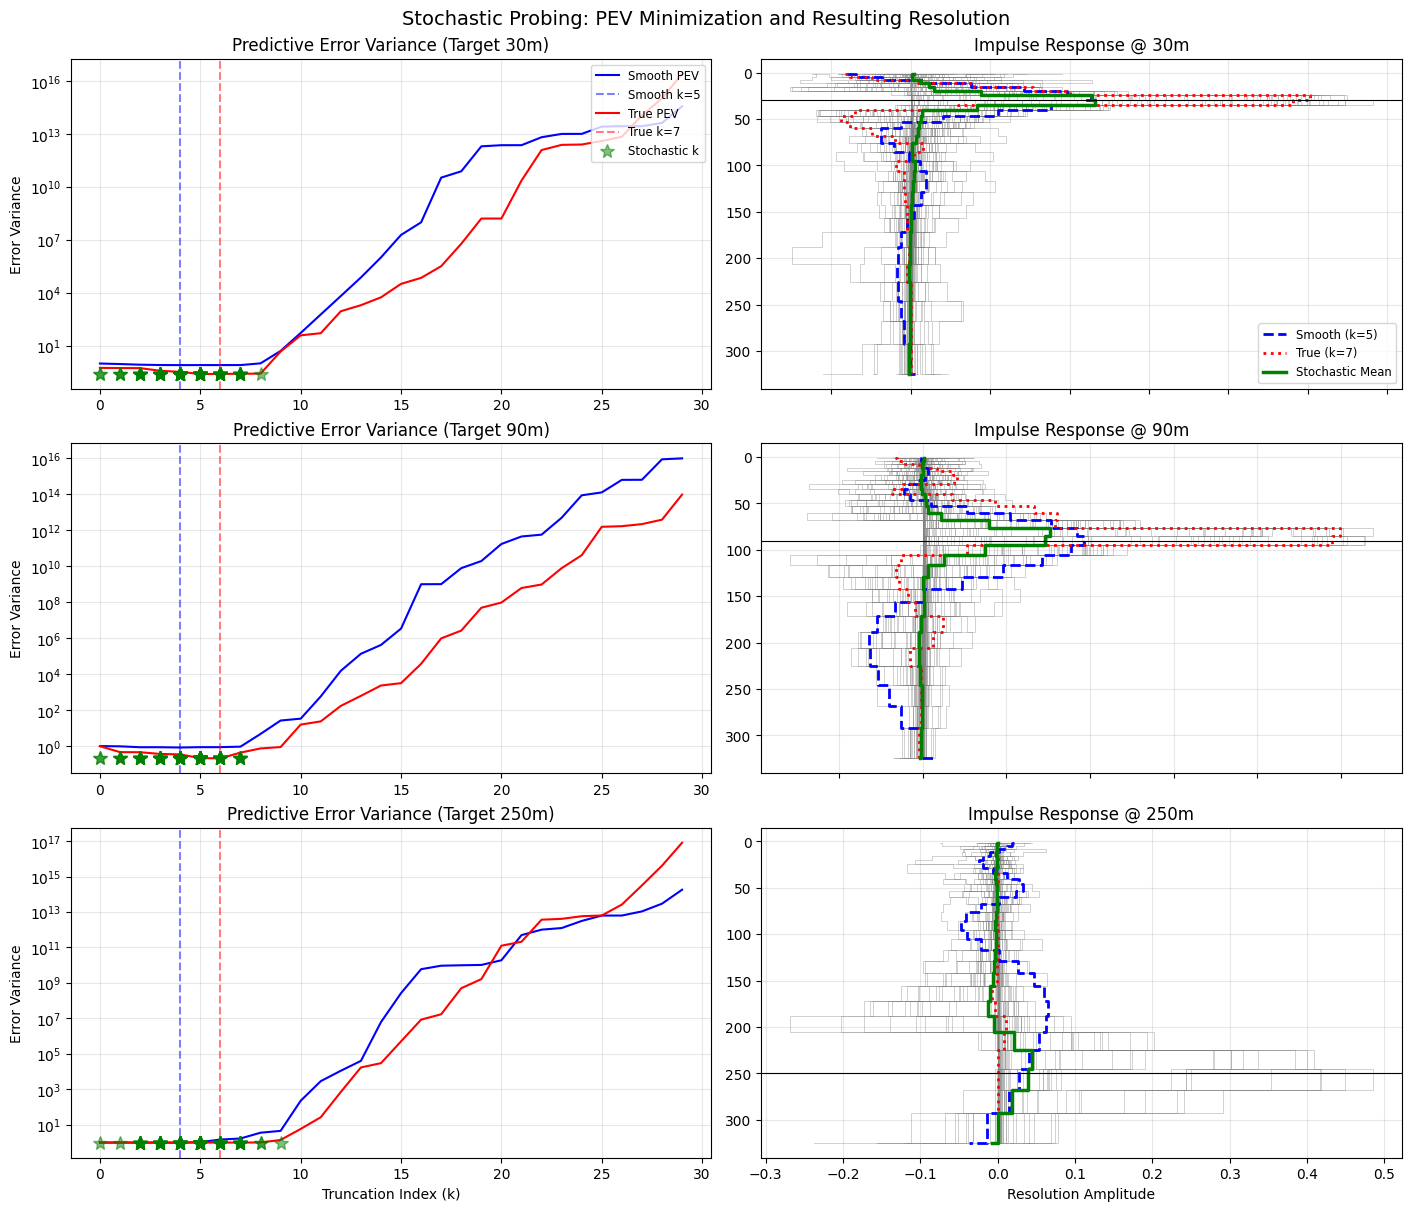

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from discretize import TensorMesh

try:
    from simpeg.solvers import ScipySolver
except ImportError:
    from pymatsolver import Solver as ScipySolver

# --- 1. SETUP SIMULATION ---
def get_condamine_simulation():
    thicknesses = np.logspace(np.log10(3.0), np.log10(25.0), 29)
    mesh = TensorMesh([(np.r_[thicknesses, thicknesses[-1]])], "0")
    
    rx_offset = np.array([13.0, 0.0, 0.0]) 
    tx_area = 1.0  
    lm_times = np.logspace(np.log10(1e-5), np.log10(1e-3), 20)
    hm_times = np.logspace(np.log10(1e-4), np.log10(1e-2), 20)
    
    src_loc = np.array([0.0, 0.0, 30.0]) 
    rx_loc = np.array([13.0, 0.0, 30.0]) 

    rx_lm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], lm_times, "z")
    rx_hm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], hm_times, "z")
    
    src_lm = tdem.sources.MagDipole([rx_lm], location=src_loc, orientation="z")
    src_hm = tdem.sources.MagDipole([rx_hm], location=src_loc, orientation="z")

    sim = tdem.Simulation1DLayered(
        survey=tdem.Survey([src_lm, src_hm]),
        thicknesses=thicknesses,
        sigmaMap=maps.ExpMap(nP=mesh.nC)
    )
    sim.solver = ScipySolver
    return sim, mesh

# --- 2. HELPER FUNCTIONS ---
def get_whitened_J(simulation, m_model, m_true):
    """
    Calculates Jacobian for m_model, but whitens it using 
    the error envelope from m_true (Observed Data).
    """
    try:
        # 1. Noise Envelope from TRUE data
        f_true = simulation.fields(m_true)
        d_true = simulation.dpred(m_true, f=f_true)
        
        # Error Model: 5% relative error + noise floor
        std_true = np.abs(d_true) * 0.03 + 1e-13
        Wd = np.diag(1.0 / std_true)
        
        # 2. Jacobian for MODEL
        f_model = simulation.fields(m_model)
        J_model = simulation.getJ(m_model, f=f_model)
        
        # 3. Whiten
        Jw = Wd @ J_model
        return np.nan_to_num(Jw)
    except Exception as e:
        return None

def calc_pev_curve(S, Vt, y, sigma_eps=1.0, prior_var=1.0):
    """Returns the full PEV curve and the optimal k index."""
    pevs = []
    n_params = len(y)
    for k in range(1, len(S) + 1):
        Vk = Vt[:k, :].T
        Sk_vals = S[:k]
        # Safety for division
        Sk_inv2 = np.diag(1.0 / (Sk_vals**2 + 1e-30))
        
        # Noise Term
        term1 = sigma_eps * (y.T @ Vk @ Sk_inv2 @ Vk.T @ y) 
        
        # Null Space Term
        R = Vk @ Vk.T
        I = np.eye(n_params)
        Null = I - R
        term2 = prior_var * (y.T @ Null @ Null.T @ y) 
        
        pevs.append(term1 + term2)
    
    pevs = np.array(pevs)
    k_opt = np.argmin(pevs) + 1
    return pevs, k_opt

def get_irf(Vt, k, target_idx):
    Vk = Vt[:k, :].T
    R = Vk @ Vk.T
    return R[target_idx, :] 

# --- 3. GENERATE STOCHASTIC MODELS ---
def generate_random_model(mesh, correlation_len=2):
    nC = mesh.nC
    idx = np.arange(nC)
    dist = np.abs(idx[:, None] - idx[None, :])
    C = np.exp(-(dist**2) / (2 * correlation_len**2)) + np.eye(nC)*1e-6
    
    try:
        L = np.linalg.cholesky(C)
    except:
        U, S, _ = np.linalg.svd(C)
        L = U @ np.diag(np.sqrt(S))
        
    z = np.random.randn(nC)
    perturbation = L @ z
    # Scale perturbation (approx +/- 2.0 log units for good variance)
    perturbation = perturbation / np.std(perturbation) * 2.0
    
    # RESTORED: Base on 0.001 S/m (Resistive Background)
    # This matches your original logic where the prior is resistive
    m_rand = np.log(0.01) + perturbation
    return m_rand

# --- 4. RUN EXPERIMENT ---
sim, mesh = get_condamine_simulation()
thicknesses = mesh.h[0][:-1]
depths = np.cumsum(np.r_[0, thicknesses])
plot_depths = (depths[:-1] + depths[1:]) / 2 
plot_depths = np.r_[plot_depths, depths[-1] + 20] 

# Targets
targets = [30.0, 90.0, 250.0]
n_realizations = 100

# Setup 2-Column Figure: Left=PEV, Right=IRF
fig, axes = plt.subplots(len(targets), 2, figsize=(14, 12), constrained_layout=True)

# Define Models
# RESTORED: Smooth Model is Resistive (0.001)
sigma_smooth = np.ones(mesh.nC) * 0.01 

# True Model is Conductive (0.01 background)
sigma_true = np.ones(mesh.nC) * 0.01
z_bot = np.cumsum(mesh.h[0]); z_top = np.r_[0, z_bot[:-1]]
sigma_true[(z_top >= 25) & (z_top < 35)] = 0.05
sigma_true[(z_top >= 80) & (z_top < 100)] = 0.1
sigma_true[(z_top >= 160) & (z_top < 200)] = 0.3

# Pre-calculate Baselines
print("Calculating Baseline Jacobians...")
# Note: Whiten both using m_true (Observation)
J_smooth = get_whitened_J(sim, np.log(sigma_smooth), np.log(sigma_true))
U_S, S_S, Vt_S = svd(J_smooth, full_matrices=False)

J_true = get_whitened_J(sim, np.log(sigma_true), np.log(sigma_true))
U_T, S_T, Vt_T = svd(J_true, full_matrices=False)

print(f"Running Stochastic Ensemble (N={n_realizations})...")

for i, t_depth in enumerate(targets):
    t_idx = np.argmin(np.abs(plot_depths - t_depth))
    target_vec = np.zeros(mesh.nC); target_vec[t_idx] = 1.0
    
    # ---------------------------
    # 1. CALCULATE CURVES & IRFs
    # ---------------------------
    
    # Smooth
    pev_curve_S, k_S = calc_pev_curve(S_S, Vt_S, target_vec)
    irf_smooth = get_irf(Vt_S, k_S, t_idx)
    
    # True
    pev_curve_T, k_T = calc_pev_curve(S_T, Vt_T, target_vec)
    irf_true = get_irf(Vt_T, k_T, t_idx)
    
    # Stochastic Loop
    irf_stack = []
    k_stochastic_dist = [] 
    
    for r in range(n_realizations):
        m_rand = generate_random_model(mesh, correlation_len=3.0)
        # Whiten using m_true (Observation)
        J_rand = get_whitened_J(sim, m_rand, np.log(sigma_true))
        
        if J_rand is not None:
            try:
                U_r, S_r, Vt_r = svd(J_rand, full_matrices=False)
                # Get k_opt for this specific realization
                _, k_rand = calc_pev_curve(S_r, Vt_r, target_vec)
                
                irf_r = get_irf(Vt_r, k_rand, t_idx)
                irf_stack.append(irf_r)
                k_stochastic_dist.append(k_rand)
            except:
                pass

    irf_stack = np.array(irf_stack)
    irf_mean = np.mean(irf_stack, axis=0)
    
    # ---------------------------
    # 2. PLOTTING
    # ---------------------------
    ax_pev = axes[i, 0] # Left Column
    ax_irf = axes[i, 1] # Right Column
    
    # --- PLOT LEFT: PEV Curves ---
    ax_pev.semilogy(pev_curve_S, 'b-', lw=1.5, label='Smooth PEV')
    ax_pev.axvline(k_S-1, color='b', ls='--', alpha=0.5, label=f'Smooth k={k_S}')
    
    ax_pev.semilogy(pev_curve_T, 'r-', lw=1.5, label='True PEV')
    ax_pev.axvline(k_T-1, color='r', ls='--', alpha=0.5, label=f'True k={k_T}')
    
    # Visualize Stochastic k distribution
    if len(k_stochastic_dist) > 0:
        ax_pev.plot(np.array(k_stochastic_dist)-1, [np.min(pev_curve_T)]*len(k_stochastic_dist), 
                    'g*', markersize=10, alpha=0.5, label='Stochastic k')
    
    ax_pev.set_title(f"Predictive Error Variance (Target {t_depth:.0f}m)")
    ax_pev.set_ylabel("Error Variance")
    if i == len(targets)-1: ax_pev.set_xlabel("Truncation Index (k)")
    ax_pev.grid(True, alpha=0.3)
    if i == 0: ax_pev.legend(loc='upper right', fontsize='small')

    # --- PLOT RIGHT: Impulse Responses ---
    # Individual Realizations
    for irf in irf_stack: 
        ax_irf.step(irf, plot_depths, color='gray', alpha=0.5, lw=0.5, where='mid')

    # Baselines
    ax_irf.step(irf_smooth, plot_depths, 'b--', lw=2.0, where='mid', label=f'Smooth (k={k_S})')
    ax_irf.step(irf_true, plot_depths, 'r:', lw=2.0, where='mid', label=f'True (k={k_T})')
    ax_irf.step(irf_mean, plot_depths, 'g-', lw=2.5, where='mid', label=f'Stochastic Mean')
    
    ax_irf.axhline(t_depth, color='k', ls='-', lw=0.8)
    ax_irf.invert_yaxis()
    ax_irf.set_title(f"Impulse Response @ {t_depth:.0f}m")
    
    if i == len(targets)-1: 
        ax_irf.set_xlabel("Resolution Amplitude")
    else:
        ax_irf.set_xticklabels([])
        
    ax_irf.grid(True, alpha=0.3)
    if i == 0: ax_irf.legend(loc='lower right', fontsize='small')

plt.suptitle("Stochastic Probing: PEV Minimization and Resulting Resolution", fontsize=14)
plt.show()

Calculating Baseline Jacobians...
Running Stochastic Ensemble (N=200) ONCE...
Successfully computed 200 valid Jacobians. Now analyzing targets...


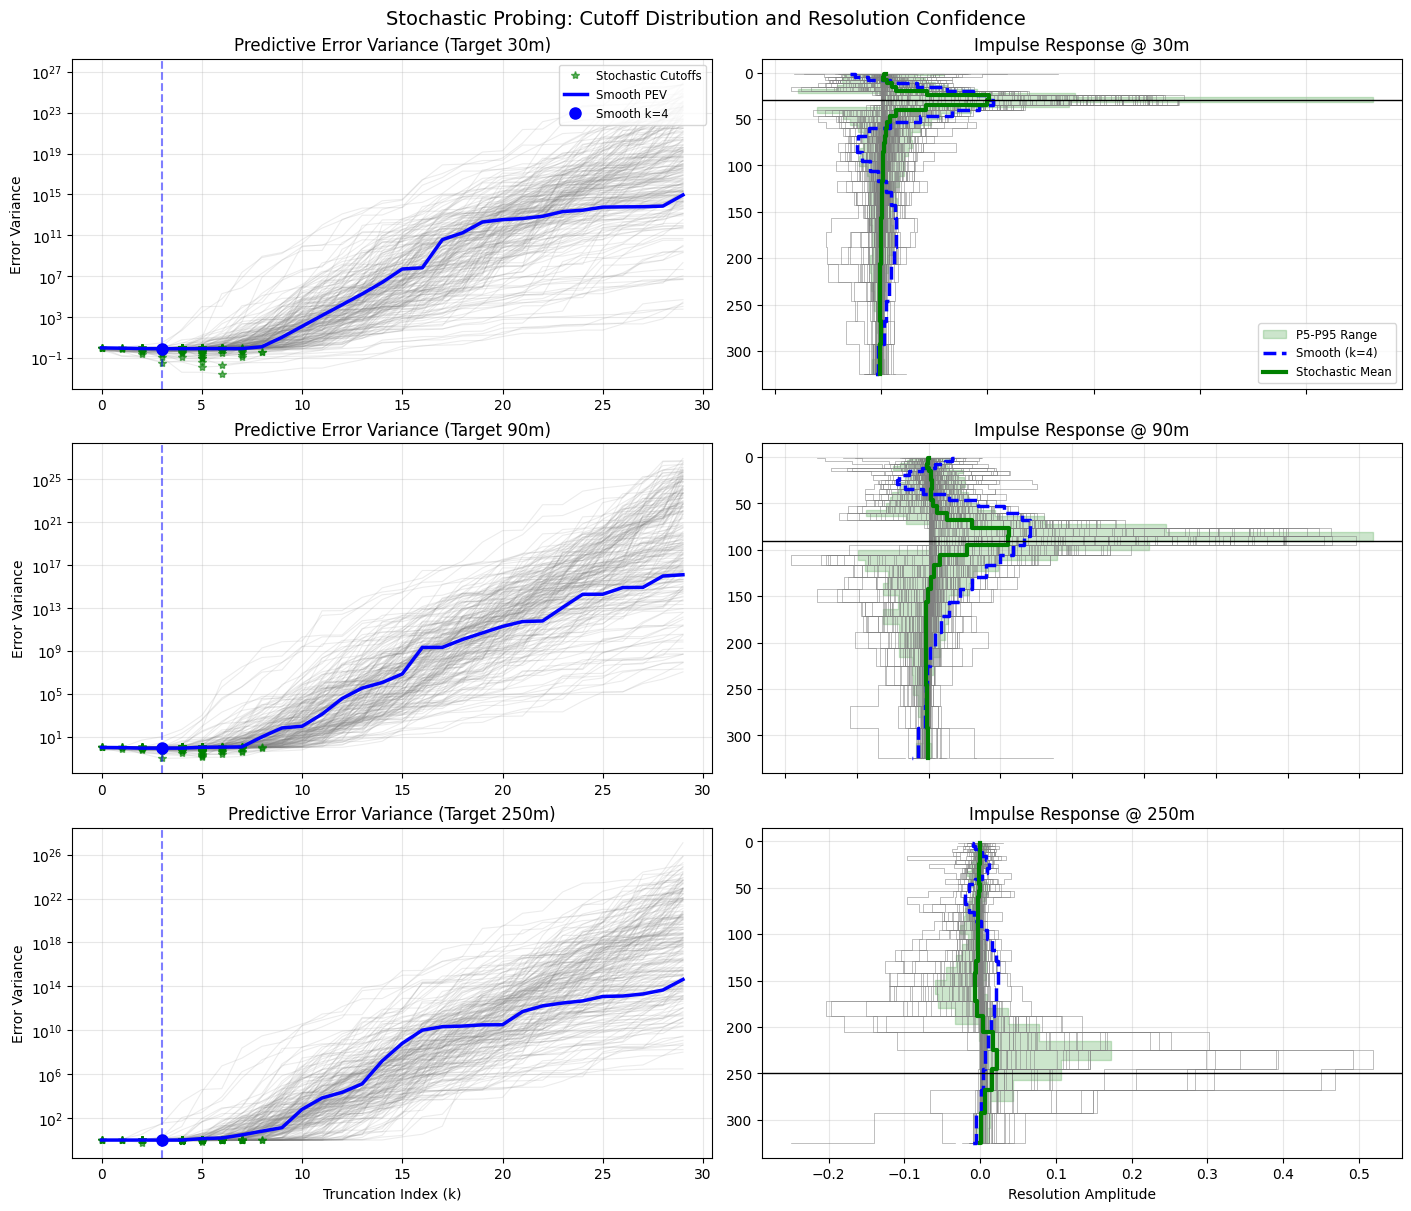

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from discretize import TensorMesh

try:
    from simpeg.solvers import ScipySolver
except ImportError:
    from pymatsolver import Solver as ScipySolver

# --- 1. SETUP SIMULATION ---
def get_condamine_simulation():
    thicknesses = np.logspace(np.log10(3.0), np.log10(25.0), 29)
    mesh = TensorMesh([(np.r_[thicknesses, thicknesses[-1]])], "0")
    
    rx_offset = np.array([13.0, 0.0, 0.0]) 
    tx_area = 1.0  
    lm_times = np.logspace(np.log10(1e-5), np.log10(1e-3), 20)
    hm_times = np.logspace(np.log10(1e-4), np.log10(1e-2), 20)
    
    src_loc = np.array([0.0, 0.0, 30.0]) 
    rx_loc = np.array([13.0, 0.0, 30.0]) 

    rx_lm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], lm_times, "z")
    rx_hm = tdem.receivers.PointMagneticFluxTimeDerivative(rx_loc[None, :], hm_times, "z")
    
    src_lm = tdem.sources.MagDipole([rx_lm], location=src_loc, orientation="z")
    src_hm = tdem.sources.MagDipole([rx_hm], location=src_loc, orientation="z")

    sim = tdem.Simulation1DLayered(
        survey=tdem.Survey([src_lm, src_hm]),
        thicknesses=thicknesses,
        sigmaMap=maps.ExpMap(nP=mesh.nC)
    )
    sim.solver = ScipySolver
    return sim, mesh

# --- 2. HELPER FUNCTIONS ---
def get_whitened_J(simulation, m_model, m_true):
    try:
        f_true = simulation.fields(m_true)
        d_true = simulation.dpred(m_true, f=f_true)
        # Error Model: 3% + Floor
        std_true = np.abs(d_true) * 0.05 + 1e-13
        Wd = np.diag(1.0 / std_true)
        
        f_model = simulation.fields(m_model)
        J_model = simulation.getJ(m_model, f=f_model)
        
        Jw = Wd @ J_model
        return np.nan_to_num(Jw)
    except Exception as e:
        return None

def calc_pev_curve(S, Vt, y, sigma_eps=1.0, prior_var=1.0):
    pevs = []
    n_params = len(y)
    for k in range(1, len(S) + 1):
        Vk = Vt[:k, :].T
        Sk_vals = S[:k]
        Sk_inv2 = np.diag(1.0 / (Sk_vals**2 + 1e-30))
        
        term1 = sigma_eps * (y.T @ Vk @ Sk_inv2 @ Vk.T @ y) 
        
        R = Vk @ Vk.T
        I = np.eye(n_params)
        Null = I - R
        term2 = prior_var * (y.T @ Null @ Null.T @ y) 
        
        pevs.append(term1 + term2)
    
    pevs = np.array(pevs)
    k_opt = np.argmin(pevs) + 1
    return pevs, k_opt

def get_irf(Vt, k, target_idx):
    Vk = Vt[:k, :].T
    R = Vk @ Vk.T
    return R[target_idx, :] 

# --- 3. GENERATE STOCHASTIC MODELS ---
def generate_random_model(mesh, correlation_len=2):
    nC = mesh.nC
    idx = np.arange(nC)
    dist = np.abs(idx[:, None] - idx[None, :])
    C = np.exp(-(dist**2) / (2 * correlation_len**2)) + np.eye(nC)*1e-6
    
    try:
        L = np.linalg.cholesky(C)
    except:
        U, S, _ = np.linalg.svd(C)
        L = U @ np.diag(np.sqrt(S))
        
    z = np.random.randn(nC)
    perturbation = L @ z
    perturbation = perturbation / np.std(perturbation) * 2.0
    
    m_rand = np.log(0.01) + perturbation
    return m_rand

# --- 4. RUN EXPERIMENT ---
sim, mesh = get_condamine_simulation()
thicknesses = mesh.h[0][:-1]
depths = np.cumsum(np.r_[0, thicknesses])
plot_depths = (depths[:-1] + depths[1:]) / 2 
plot_depths = np.r_[plot_depths, depths[-1] + 20] 

targets = [30.0, 90.0, 250.0]
n_realizations = 200

fig, axes = plt.subplots(len(targets), 2, figsize=(14, 12), constrained_layout=True)

sigma_smooth = np.ones(mesh.nC) * 0.01 
sigma_true = np.ones(mesh.nC) * 0.01
z_bot = np.cumsum(mesh.h[0]); z_top = np.r_[0, z_bot[:-1]]
sigma_true[(z_top >= 25) & (z_top < 35)] = 0.05
sigma_true[(z_top >= 80) & (z_top < 100)] = 0.1
sigma_true[(z_top >= 200) & (z_top < 250)] = 0.3

# ... (Everything above this stays exactly the same) ...

print("Calculating Baseline Jacobians...")
J_smooth = get_whitened_J(sim, np.log(sigma_smooth), np.log(sigma_true))
U_S, S_S, Vt_S = svd(J_smooth, full_matrices=False)

print(f"Running Stochastic Ensemble (N={n_realizations}) ONCE...")

# 1. PRE-COMPUTE ALL 200 SVDs FIRST
stochastic_svds = []
for r in range(n_realizations):
    m_rand = generate_random_model(mesh, correlation_len=3.0)
    J_rand = get_whitened_J(sim, m_rand, np.log(sigma_true))
    
    if J_rand is not None:
        try:
            U_r, S_r, Vt_r = svd(J_rand, full_matrices=False)
            stochastic_svds.append((S_r, Vt_r)) # Save the SVD outputs
        except:
            pass

print(f"Successfully computed {len(stochastic_svds)} valid Jacobians. Now analyzing targets...")

# 2. LOOP OVER TARGET DEPTHS (Fast, no forward modeling in here!)
for i, t_depth in enumerate(targets):
    t_idx = np.argmin(np.abs(plot_depths - t_depth))
    target_vec = np.zeros(mesh.nC); target_vec[t_idx] = 1.0
    
    # Smooth Baseline
    pev_curve_S, k_S = calc_pev_curve(S_S, Vt_S, target_vec)
    irf_smooth = get_irf(Vt_S, k_S, t_idx)
    
    # Stochastic Analytics
    irf_stack = []
    pev_stack = [] 
    k_opt_stack = [] 
    pev_min_stack = [] 
    
    # Iterate through the pre-computed SVDs
    for S_r, Vt_r in stochastic_svds:
        pev_r, k_r = calc_pev_curve(S_r, Vt_r, target_vec)
        irf_r = get_irf(Vt_r, k_r, t_idx)
        
        pev_stack.append(pev_r)
        irf_stack.append(irf_r)
        k_opt_stack.append(k_r)
        pev_min_stack.append(pev_r[k_r-1])

    irf_stack = np.array(irf_stack)
    irf_mean = np.mean(irf_stack, axis=0)
    
    # ... (Plotting code remains exactly the same) ...
    # CALCULATE PERCENTILES (P5 and P95)
    irf_p5 = np.percentile(irf_stack, 5, axis=0)
    irf_p95 = np.percentile(irf_stack, 95, axis=0)
    
    # --- 3. PLOTTING ---
    ax_pev = axes[i, 0] 
    ax_irf = axes[i, 1] 
    
    # --- PLOT LEFT: PEV Curves ---
    for pev_curve in pev_stack:
        ax_pev.semilogy(pev_curve, color='gray', alpha=0.15, lw=0.8)
    
    ax_pev.plot(np.array(k_opt_stack)-1, pev_min_stack, 
               'g*', ms=6, alpha=0.6, label='Stochastic Cutoffs')

    ax_pev.semilogy(pev_curve_S, 'b-', lw=2.5, label='Smooth PEV')
    ax_pev.plot(k_S-1, pev_curve_S[k_S-1], 'bo', ms=8, label=f'Smooth k={k_S}')
    ax_pev.axvline(k_S-1, color='b', ls='--', alpha=0.5)
    
    ax_pev.set_title(f"Predictive Error Variance (Target {t_depth:.0f}m)")
    ax_pev.set_ylabel("Error Variance")
    if i == len(targets)-1: ax_pev.set_xlabel("Truncation Index (k)")
    ax_pev.grid(True, alpha=0.3)
    if i == 0: ax_pev.legend(loc='upper right', fontsize='small')

    # --- PLOT RIGHT: Impulse Responses ---
    
    # 1. Fill P5-P95 Confidence Interval (Green Shade)
    ax_irf.fill_betweenx(plot_depths, irf_p5, irf_p95, 
                        color='g', alpha=0.2, step='mid', label='P5-P95 Range')
    
    # 2. Grey Spaghetti (Individual Realizations)
    for irf in irf_stack: 
        ax_irf.step(irf, plot_depths, color='gray', alpha=0.7, lw=0.5, where='mid')

    # 3. Smooth Baseline (Blue)
    ax_irf.step(irf_smooth, plot_depths, 'b--', lw=2.5, where='mid', label=f'Smooth (k={k_S})')
    
    # 4. Stochastic Mean (Green Solid)
    ax_irf.step(irf_mean, plot_depths, 'g-', lw=3.0, where='mid', label=f'Stochastic Mean')
    
    ax_irf.axhline(t_depth, color='k', ls='-', lw=1.0)
    ax_irf.invert_yaxis()
    ax_irf.set_title(f"Impulse Response @ {t_depth:.0f}m")
    
    if i == len(targets)-1: 
        ax_irf.set_xlabel("Resolution Amplitude")
    else:
        ax_irf.set_xticklabels([])
        
    ax_irf.grid(True, alpha=0.3)
    if i == 0: ax_irf.legend(loc='lower right', fontsize='small')

plt.suptitle("Stochastic Probing: Cutoff Distribution and Resolution Confidence", fontsize=14)

plt.savefig('Resolution matrix.png')
